
# Glassdoor Jobs Salary Analysis - EDA

## Project Summary
This project focuses on performing Exploratory Data Analysis (EDA) on the Glassdoor jobs dataset. 
The objective is to understand salary trends, company ratings, job roles, industries, and other factors 
that influence salary distribution in the dataset.

## Problem Statement
The recruitment industry generates a huge amount of job-related data every day. Companies post jobs with 
different salary ranges, ratings, locations, and industry requirements. Analyzing this data can help identify 
important trends related to salaries, popular job roles, and hiring patterns.

## Business Objective
- Analyze salary distributions across industries and sectors.
- Identify the most common job roles and locations.
- Understand the relationship between company ratings and salaries.
- Prepare cleaned data for machine learning model development.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv("C:\\Users\\sreer\\Downloads\\glassdoor_jobs.csv")

# Display first 5 rows
print(df.head())

   Unnamed: 0                  Job Title              Salary Estimate  \
0           0             Data Scientist   $53K-$91K (Glassdoor est.)   
1           1  Healthcare Data Scientist  $63K-$112K (Glassdoor est.)   
2           2             Data Scientist   $80K-$90K (Glassdoor est.)   
3           3             Data Scientist   $56K-$97K (Glassdoor est.)   
4           4             Data Scientist  $86K-$143K (Glassdoor est.)   

                                     Job Description  Rating  \
0  Data Scientist\nLocation: Albuquerque, NM\nEdu...     3.8   
1  What You Will Do:\n\nI. General Summary\n\nThe...     3.4   
2  KnowBe4, Inc. is a high growth information sec...     4.8   
3  *Organization and Job ID**\nJob ID: 310709\n\n...     3.8   
4  Data Scientist\nAffinity Solutions / Marketing...     2.9   

                                 Company Name         Location  \
0                      Tecolote Research\n3.8  Albuquerque, NM   
1  University of Maryland Medical System\n3.

In [7]:
print("Shape of Dataset:", df.shape)
print("\nColumn Names:\n", df.columns)
print("\nDataset Info:\n")
df.info()

Shape of Dataset: (956, 15)

Column Names:
 Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='str')

Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    str    
 2   Salary Estimate    956 non-null    str    
 3   Job Description    956 non-null    str    
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    str    
 6   Location           956 non-null    str    
 7   Headquarters       956 non-null    str    
 8   Size               956 non-null    str    
 9   Founded            956 non-null    int64  
 10  Type of ownership

In [8]:
print(df.describe())

       Unnamed: 0      Rating      Founded
count  956.000000  956.000000   956.000000
mean   477.500000    3.601255  1774.605649
std    276.117729    1.067619   598.942517
min      0.000000   -1.000000    -1.000000
25%    238.750000    3.300000  1937.000000
50%    477.500000    3.800000  1992.000000
75%    716.250000    4.200000  2008.000000
max    955.000000    5.000000  2019.000000


In [9]:
missing_values = df.isnull().sum()
print(missing_values)

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64


In [10]:
df.drop_duplicates(inplace=True)
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (956, 15)


In [12]:
# Remove unwanted text
salary = df['Salary Estimate'].str.replace('(Glassdoor est.)', '', regex=False)
salary = salary.str.replace('(Employer est.)', '', regex=False)
salary = salary.str.replace('$', '', regex=False)
salary = salary.str.replace('K', '', regex=False)

# Keep only valid salary rows
valid_rows = salary[salary != '-1']

salary_min = []
salary_max = []
valid_index = []

for idx, value in valid_rows.items():
    try:
        split_salary = value.split('-')

        min_sal = int(split_salary[0].strip())
        max_sal = int(split_salary[1].strip())

        salary_min.append(min_sal)
        salary_max.append(max_sal)

        valid_index.append(idx)

    except:
        pass

# Keep only successfully processed rows
df = df.loc[valid_index].copy()

# Add cleaned salary columns
df['min_salary'] = salary_min
df['max_salary'] = salary_max
df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2

# Check result
print(df[['Salary Estimate', 'min_salary', 'max_salary', 'avg_salary']].head())

               Salary Estimate  min_salary  max_salary  avg_salary
0   $53K-$91K (Glassdoor est.)          53          91        72.0
1  $63K-$112K (Glassdoor est.)          63         112        87.5
2   $80K-$90K (Glassdoor est.)          80          90        85.0
3   $56K-$97K (Glassdoor est.)          56          97        76.5
4  $86K-$143K (Glassdoor est.)          86         143       114.5


In [13]:
print(df.isnull().sum())

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
min_salary           0
max_salary           0
avg_salary           0
dtype: int64


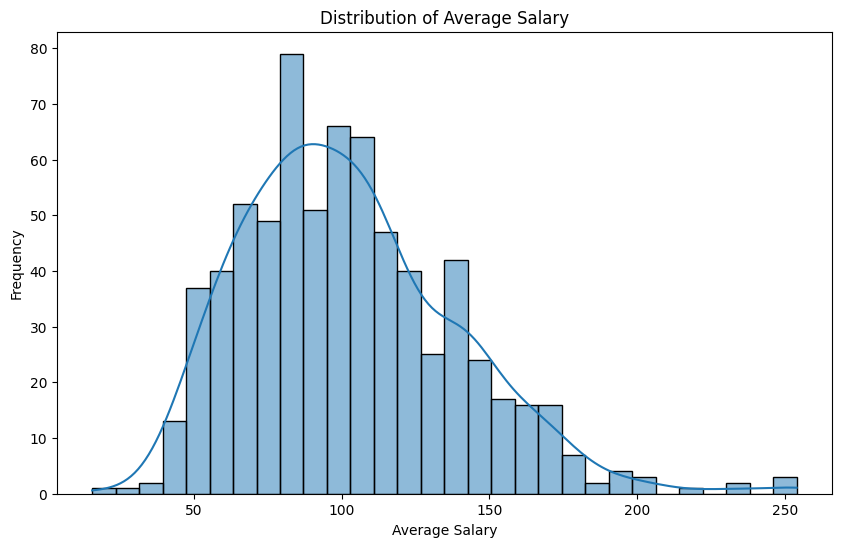

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['avg_salary'], bins=30, kde=True)
plt.title('Distribution of Average Salary')
plt.xlabel('Average Salary')
plt.ylabel('Frequency')
plt.show()

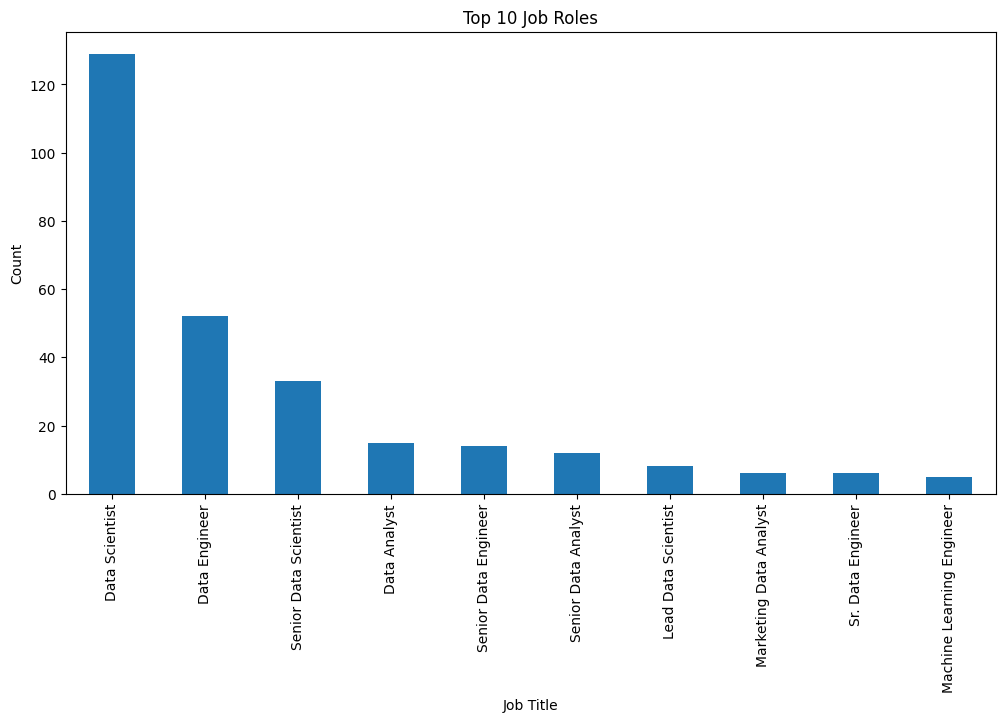

In [16]:
plt.figure(figsize=(12,6))
df['Job Title'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Job Roles')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.show()

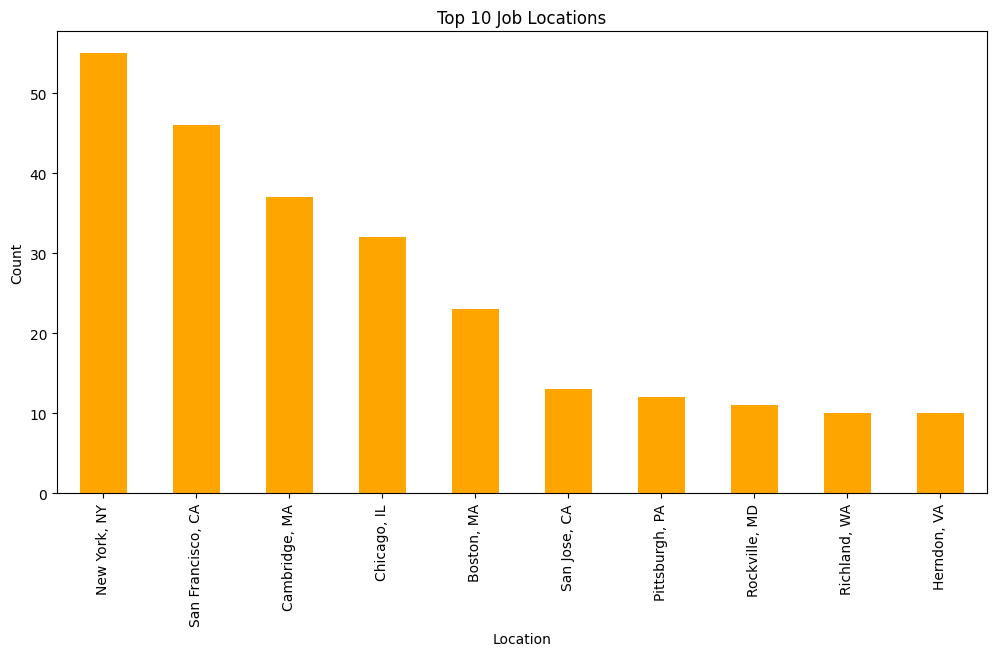

In [17]:
plt.figure(figsize=(12,6))
df['Location'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Job Locations')
plt.xlabel('Location')
plt.ylabel('Count')
plt.show()

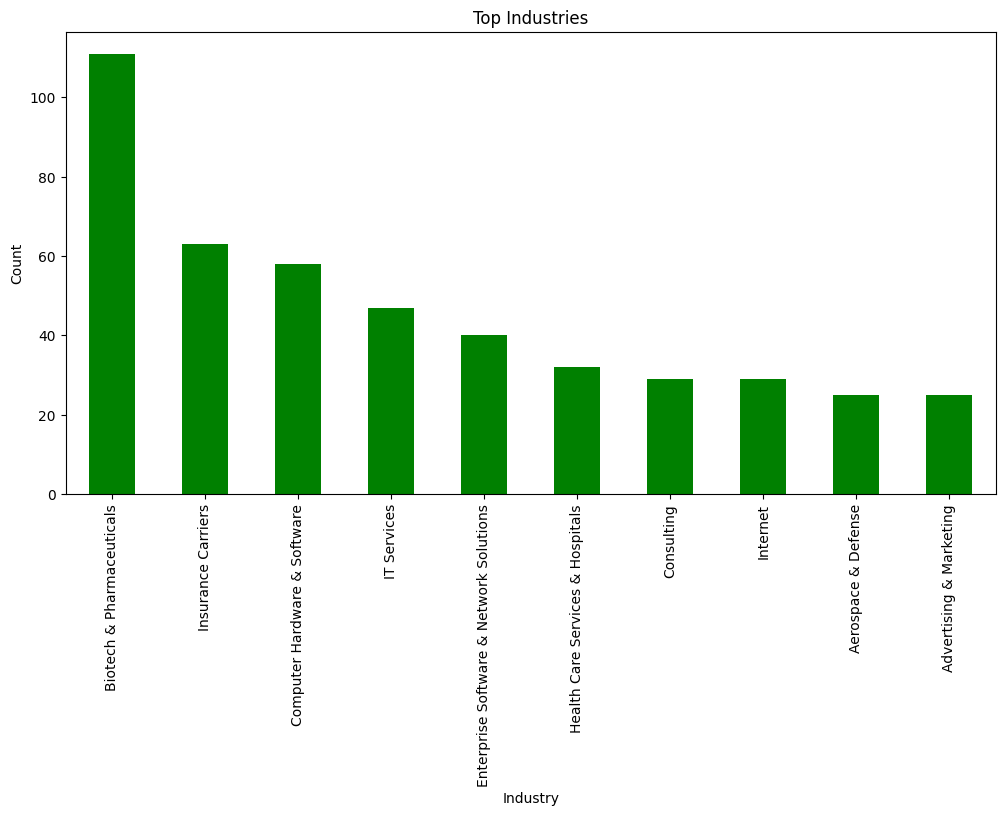

In [18]:
plt.figure(figsize=(12,6))
df['Industry'].value_counts().head(10).plot(kind='bar', color='green')
plt.title('Top Industries')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.show()

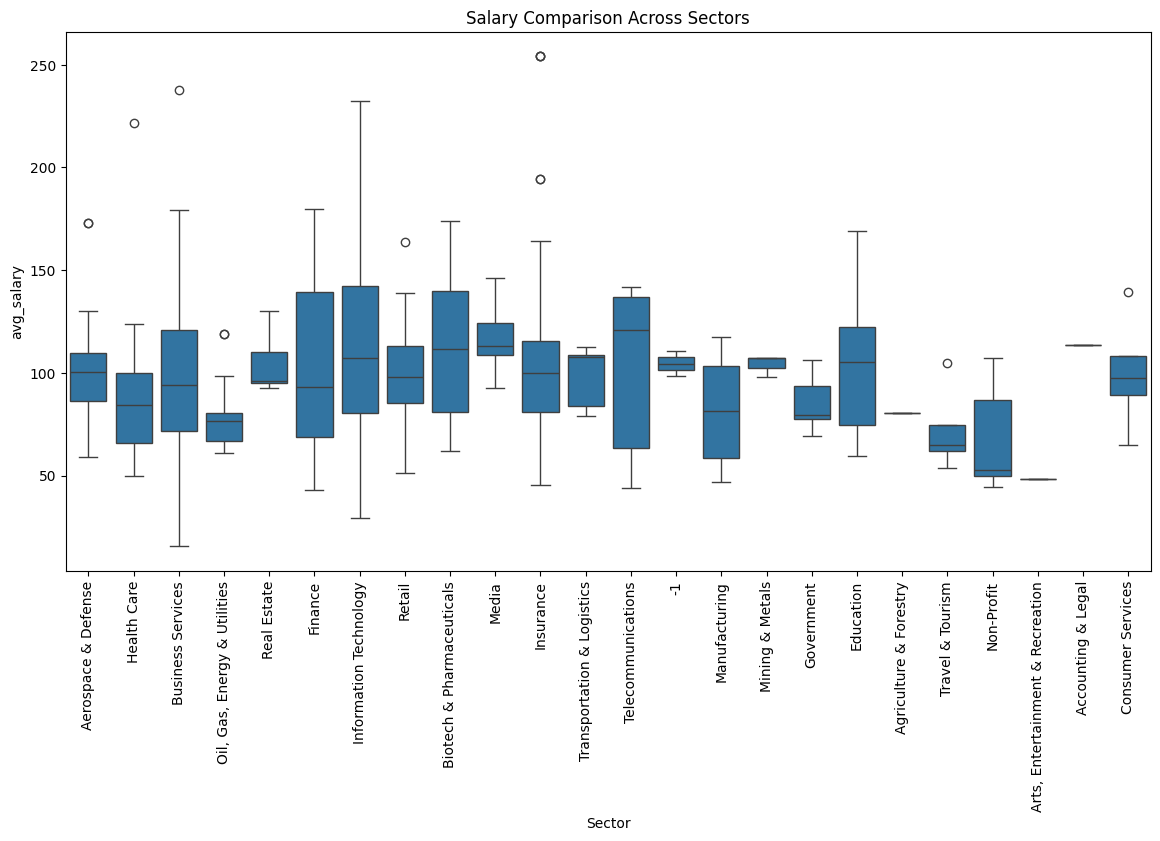

In [19]:
plt.figure(figsize=(14,7))
sns.boxplot(x='Sector', y='avg_salary', data=df)
plt.xticks(rotation=90)
plt.title('Salary Comparison Across Sectors')
plt.show()

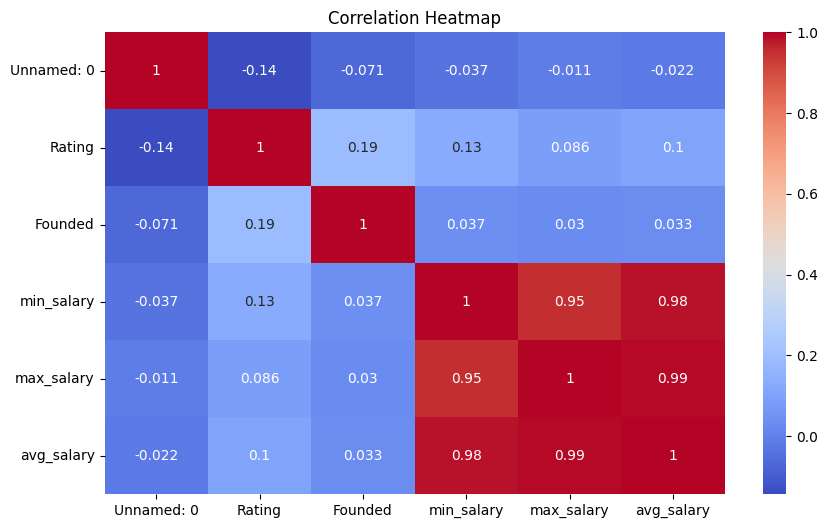

In [20]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:

selected_features = ['Rating', 'avg_salary']

if 'Company Age' in df.columns:
    selected_features.append('Company Age')

pairplot_df = df[selected_features].dropna()

sns.pairplot(pairplot_df)
plt.show()
